In [1]:
#Fitting w0waCDM with reduced noise

import numpy as np
import pandas as pd

from astropy.io import fits
from astropy.cosmology import w0waCDM

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.lines as mlines

import statistics as stat

import scipy.stats as stats
from scipy import optimize
from scipy.stats import spearmanr
from scipy.stats import ks_2samp
from scipy.stats import chi2_contingency
from scipy.integrate import quad
from scipy.optimize import curve_fit
from scipy.stats import norm

from nautilus import Prior
import nautilus.sampler as ns
from nautilus import Sampler

import corner
from corner import quantile

from astropy.cosmology import FlatLambdaCDM
from astropy.cosmology import wCDM
from astropy.cosmology import w0waCDM

import camb
from camb import model, initialpower
from camb.baseconfig import CAMBError

import h5py

from sklearn.metrics import r2_score

ns.h5py = h5py

print("Hello world")

Hello world


In [2]:
#Check all dependencies
import numpy, scipy, matplotlib, pandas, astropy, sklearn, h5py, camb, corner, anesthetic, nautilus

print("numpy:", numpy.__version__)
print("scipy:", scipy.__version__)
print("matplotlib:", matplotlib.__version__)
print("pandas:", pandas.__version__)
print("astropy:", astropy.__version__)
print("sklearn:", sklearn.__version__)
print("h5py:", h5py.__version__)
print("camb:", camb.__version__)
print("corner:", corner.__version__)
print("anesthetic:", anesthetic.__version__)
print("nautilus:", nautilus.__version__)

numpy: 2.4.0
scipy: 1.16.3
matplotlib: 3.10.8
pandas: 2.3.3
astropy: 7.2.0
sklearn: 1.7.2
h5py: 3.15.1
camb: 1.6.5
corner: 2.2.3
anesthetic: 2.11.0
nautilus: 1.0.5


In [3]:
#Reading the real data CSV file
df = pd.read_csv(
    'DES-Dovekie_HD.csv',
    comment='#',
    sep=r'\s+',
    engine='python'
)

In [4]:
#Selecting only the DES, CFA3, CFA4, CSP and Foundation Sne with zHD>=0.025 and a Probability of being SN1a above 0.9
allowed = [10, 63, 64, 65, 66, 150]

filtered = df[
    (df["IDSURVEY"].isin(allowed)) &
    (df["zHD"] >= 0.025) &
    #(df["MUERR"] < 1)
    (df["PROBIA_BEAMS"] > 0.9)
]

filtered.to_csv("filtered_supernova.csv", index=False)

In [5]:
#Reading the new resulting dataset
sn_real = pd.read_csv(
    'filtered_supernova.csv',
    engine='python'
)

len(sn_real)

1687

In [6]:
#Making an array with only the redshift and only the muerr
real_z = np.zeros(len(sn_real))
for i in range(len(sn_real)):
    real_z[i] = sn_real.iloc[i, 3]

real_muerr = np.zeros(len(sn_real))
for i in range(len(sn_real)):
    real_muerr[i] = sn_real.iloc[i, 6]

#Isolating the MU so we can compare later on with our synthetic data
real_mu = np.zeros(len(sn_real))
for i in range(len(sn_real)):
    real_mu[i] = sn_real.iloc[i, 5]
    
real_zHEL = np.zeros(len(sn_real))
for i in range(len(sn_real)):
    real_zHEL[i] = sn_real.iloc[i, 4]

/var/folders/57/ktpx8y8144db4y3g4zw8wdl00000gn/T/ipykernel_79882/443687077.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


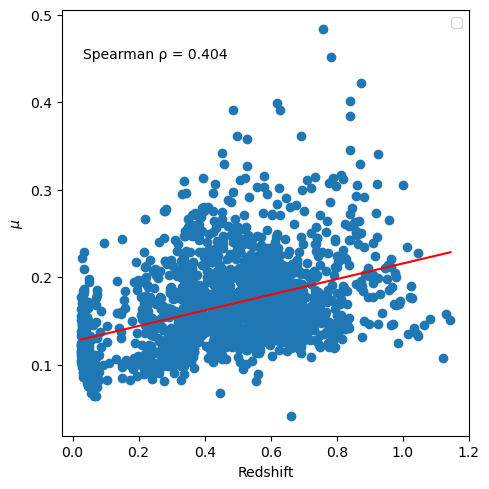

Spearman correlation: 0.40415548510908234 2.676282160967932e-67


In [7]:
#Plot muerr against z to see the correlation
plt.figure(figsize=[5,5])

# Scatter plot
plt.scatter(real_z, real_muerr)

# Line of best fit
m, b = np.polyfit(real_z, real_muerr, 1)  # slope and intercept
plt.plot(real_z, m*real_z + b, color='red')

plt.xlabel("Redshift")
plt.ylabel(r"$\mu$")

# Pearson correlation
pearson_corr = sn_real['zHD'].corr(sn_real['MUERR'])

# Spearman correlation
spearman_corr, p_value = spearmanr(real_z, real_muerr)

# Put correlation values on the plot
plt.text(
    0.05, 0.95,
    f"\nSpearman ρ = {spearman_corr:.3f}",
    transform=plt.gca().transAxes,
    verticalalignment='top'
)

plt.legend()
plt.tight_layout()
plt.show()
print("Spearman correlation:", spearman_corr, p_value)

In [8]:
#Functions to calculate likelihoods
def CMB_log_likelihood(CMB_model, CMB, inv_cov):
    delta = np.array([CMB_model - CMB])
    deltaT = np.transpose(delta)
    chi2 = np.sum(delta @ inv_cov @ deltaT)
    return -0.5*chi2

def BAO_log_likelihood(BAO_model, BAO, inv_cov):
    delta = np.array([BAO_model - BAO])
    deltaT = np.transpose(delta)
    chi2 = np.sum(delta @ inv_cov @ deltaT)
    return -0.5*chi2

def cov_log_likelihood(mu_model, mu, inv_cov):
    delta = np.array(mu_model) - np.array(mu)
    deltaT = np.transpose(delta)
    chit2 = np.sum(delta @ inv_cov @ deltaT)
    B = np.sum(delta @ inv_cov)
    C = np.sum(inv_cov)
    chi2 = chit2 - (B**2 / C) + np.log(C / (2 * np.pi))
    return -0.5*chi2


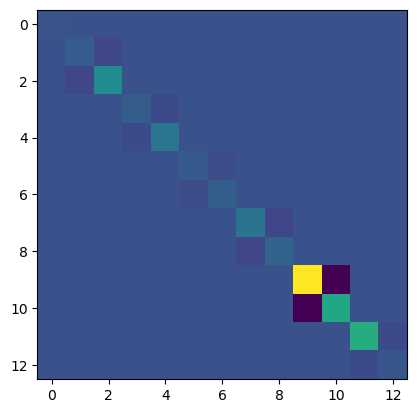

In [9]:
#Covarience matrix for BAO and CMB

corr_CMB1 = [[1, 0.46, -0.66],[0.46, 1, -0.33],[-0.66, -0.33, 1]]
corr_CMB = np.array(corr_CMB1)

sigmas = np.array([0.0046, 0.0895, 0.00015])

cov_CMB = np.diag(sigmas) @ corr_CMB @ np.diag(sigmas)

# Inverse covariance (precision matrix)
inv_CMB = np.linalg.inv(cov_CMB)

#BAO cov
#Reduce by 40%
zeff = np.array([0.295, 0.510, 0.706, 0.934, 1.321, 1.484, 2.330])
BAO_errors1 = [0.075, 0.167, 0.425, 0.177, 0.330, 0.152, 0.193, 0.318, 0.221, 0.760, 0.516, 0.531, 0.101]

BAO_errors = []
for i in range(len(BAO_errors1)):
    BAO_errors.append(BAO_errors1[i]*0.6)

BAO_corr = [-0.459, -0.404, -0.416, -0.434, -0.500, -0.431]
BAO_sd = []

for i in range(len(BAO_errors)):
    BAO_sd.append(BAO_errors[i]**2)

BAO_cov = np.diag(BAO_sd)
for i, rho in enumerate(BAO_corr):
    dm_idx = 2*i + 1
    dh_idx = 2*i + 2

    cov = rho * BAO_errors[dm_idx] * BAO_errors[dh_idx]
    BAO_cov[dm_idx, dh_idx] = cov
    BAO_cov[dh_idx, dm_idx] = cov
    
inv_BAO = np.linalg.inv(BAO_cov)

plt.imshow(BAO_cov)

cng = np.random.default_rng()
bng = np.random.default_rng()
rng = np.random.default_rng()

In [10]:
def MU(z, zHEL):
    result = 5 * np.log10((1 + zHEL)* results.comoving_radial_distance(z)) + 25
    return result

In [11]:
#All likelyhoods and priors

def likelyhoodSN_w0waCDM(theta):
    Om0 = theta['Om0']
    w0=theta['w0']
    wa=theta['wa']
    omb=theta['omb']
    H0=theta['H0']
    
    #Enforcing w0+wa<0, any time this combination occurs, likelyhood returned is -infinity

    if w0 + wa >= 0:
        return -np.inf
    
    h = H0 / 100.0
    ombh2 = omb * (h**2)
    omch2 = Om0*(h**2) - ombh2
    ommh2 = Om0*(h**2)
        
    try:
        pars = camb.CAMBparams()
        pars.set_cosmology(H0=H0,
            ombh2=ombh2,
            omch2=omch2,
            omk=0)
        
        pars.set_dark_energy(
        w=w0,
        wa=wa,
        dark_energy_model='ppf'
        )

        results = camb.get_background(pars)

        test_mu = []
        for i in range(1500):
            test_mu.append(MU(synth_z[i],synth_zHEL[i]))

        return cov_log_likelihood(test_mu, synth_mu, inv_SN)

    except CAMBError:
        return -np.inf
    
#BAO likelyhood:
def likelyhoodBAO_w0waCDM(theta):
    Om0 = theta['Om0']
    w0=theta['w0']
    wa=theta['wa']
    omb=theta['omb']
    H0=theta['H0']
    
    h = H0 / 100.0
    ombh2 = omb * (h**2)
    omch2 = Om0*(h**2) - ombh2
    ommh2 = Om0*(h**2)
    
    if w0 + wa >= 0:
        return -np.inf
    
    try:
        pars = camb.CAMBparams()
        pars.set_cosmology(H0=H0,
            ombh2=ombh2,
            omch2=omch2,
            omk=0)
        
        pars.set_dark_energy(
        w=w0,
        wa=wa,
        dark_energy_model='ppf'
        )

        results = camb.get_background(pars)
        
        r_d = results.get_derived_params()['rdrag']
        H = results.hubble_parameter(zeff)
        Dm = (1 + zeff) * results.angular_diameter_distance(zeff)
        Dm_rd = Dm /r_d
        Dh = c/H
        Dh_rd = Dh/r_d
        
        BAO_test = np.zeros(13)
        
        BAO_test[0] = (zeff[0]*(Dm[0]**2)*Dh[0])**(1/3)/r_d
        BAO_test[1] = Dm_rd[1]
        BAO_test[2] = Dh_rd[1]
        BAO_test[3] = Dm_rd[2]
        BAO_test[4] = Dh_rd[2]
        BAO_test[5] = Dm_rd[3]
        BAO_test[6] = Dh_rd[3]
        BAO_test[7] = Dm_rd[4]
        BAO_test[8] = Dh_rd[4]
        BAO_test[9] = Dm_rd[5]
        BAO_test[10] = Dh_rd[5]
        BAO_test[11] = Dm_rd[6]
        BAO_test[12] = Dh_rd[6]

        return BAO_log_likelihood(BAO_test, BAO_synth, inv_BAO)
    
    except CAMBError:
        return -np.inf
    
def likelyhoodCMB_w0waCDM(theta):
    Om0 = theta['Om0']
    w0=theta['w0']
    wa=theta['wa']
    omb=theta['omb']
    H0=theta['H0']
    
    h = H0 / 100.0
    ombh2 = omb * (h**2)
    omch2 = Om0*(h**2) - ombh2
    ommh2 = Om0*(h**2)
    
    if w0 + wa >= 0:
        return -np.inf
    
    try:
        pars = camb.CAMBparams()
        pars.set_cosmology(H0=H0,
            ombh2=ombh2,
            omch2=omch2,
            omk=0)
        
        pars.set_dark_energy(
        w=w0,
        wa=wa,
        dark_energy_model='ppf'
        )

        results = camb.get_background(pars)
        CMB_test = np.zeros(3)

        g_1 = (0.0783 * (ombh2 ** -0.238))/(1.0 + 39.5 * (ombh2 ** 0.763))
        g_2 = 0.560/(1.0 + 21.1 * (ombh2 ** 1.81))
        zstar = 1048.0 *(1.0 +0.00124 * (ombh2 ** -0.738)) *(1.0 + g_1 * (ommh2 ** g_2))

        #Calculate R
        CMB_test[0] = ((1+zstar) * results.angular_diameter_distance(zstar)*np.sqrt(Om0 * (H0**2)))/c
        #Calculate la
        CMB_test[1] = ((1+zstar) * np.pi * results.angular_diameter_distance(zstar))/results.sound_horizon(zstar)
        #Input ombh2
        CMB_test[2] = ombh2

        return CMB_log_likelihood(CMB_test, CMB_synth, inv_CMB)
    
    except CAMBError:
        return -np.inf
    
#######################################
    
def likelyhoodSN_wCDM(theta):
    Om0 = theta['Om0']
    w0=theta['w0']
    omb=theta['omb']
    H0=theta['H0']
    
    h = H0 / 100.0
    ombh2 = omb * (h**2)
    omch2 = Om0*(h**2) - ombh2
    ommh2 = Om0*(h**2)
        
    try:
        pars = camb.CAMBparams()
        pars.set_cosmology(H0=H0,
            ombh2=ombh2,
            omch2=omch2,
            omk=0)
        
        pars.set_dark_energy(
        w=w0,
        dark_energy_model='ppf'
        )

        results = camb.get_background(pars)

        test_mu = []
        for i in range(1500):
            test_mu.append(MU(synth_z[i],synth_zHEL[i]))

        return cov_log_likelihood(test_mu, synth_mu, inv_SN)
    
    except CAMBError:
        return -np.inf


def likelyhoodBAO_wCDM(theta):
    Om0 = theta['Om0']
    w0=theta['w0']
    omb=theta['omb']
    H0=theta['H0']
    
    h = H0 / 100.0
    ombh2 = omb * (h**2)
    omch2 = Om0*(h**2) - ombh2
    ommh2 = Om0*(h**2)
    
    try:
        pars = camb.CAMBparams()
        pars.set_cosmology(H0=H0,
            ombh2=ombh2,
            omch2=omch2,
            omk=0)
        
        pars.set_dark_energy(
        w=w0,
        dark_energy_model='ppf'
        )

        results = camb.get_background(pars)
        
        r_d = results.get_derived_params()['rdrag']
        H = results.hubble_parameter(zeff)
        Dm = (1 + zeff) * results.angular_diameter_distance(zeff)
        Dm_rd = Dm /r_d
        Dh = c/H
        Dh_rd = Dh/r_d
        
        BAO_test = np.zeros(13)
        
        BAO_test[0] = (zeff[0]*(Dm[0]**2)*Dh[0])**(1/3)/r_d
        BAO_test[1] = Dm_rd[1]
        BAO_test[2] = Dh_rd[1]
        BAO_test[3] = Dm_rd[2]
        BAO_test[4] = Dh_rd[2]
        BAO_test[5] = Dm_rd[3]
        BAO_test[6] = Dh_rd[3]
        BAO_test[7] = Dm_rd[4]
        BAO_test[8] = Dh_rd[4]
        BAO_test[9] = Dm_rd[5]
        BAO_test[10] = Dh_rd[5]
        BAO_test[11] = Dm_rd[6]
        BAO_test[12] = Dh_rd[6]

        return BAO_log_likelihood(BAO_test, BAO_synth, inv_BAO)
    
    except CAMBError:
        return -np.inf

def likelyhoodCMB_wCDM(theta):
    Om0 = theta['Om0']
    w0=theta['w0']
    omb=theta['omb']
    H0=theta['H0']
    
    h = H0 / 100.0
    ombh2 = omb * (h**2)
    omch2 = Om0*(h**2) - ombh2
    ommh2 = Om0*(h**2)
    
    try:
        pars = camb.CAMBparams()
        pars.set_cosmology(H0=H0,
            ombh2=ombh2,
            omch2=omch2,
            omk=0)
        
        pars.set_dark_energy(
        w=w0,
        dark_energy_model='ppf'
        )

        results = camb.get_background(pars)
        CMB_test = np.zeros(3)

        g_1 = (0.0783 * (ombh2 ** -0.238))/(1.0 + 39.5 * (ombh2 ** 0.763))
        g_2 = 0.560/(1.0 + 21.1 * (ombh2 ** 1.81))
        zstar = 1048.0 *(1.0 +0.00124 * (ombh2 ** -0.738)) *(1.0 + g_1 * (ommh2 ** g_2))

        #Calculate R
        CMB_test[0] = ((1+zstar) * results.angular_diameter_distance(zstar)*np.sqrt(Om0 * (H0**2)))/c
        #Calculate la
        CMB_test[1] = ((1+zstar) * np.pi * results.angular_diameter_distance(zstar))/results.sound_horizon(zstar)
        #Input ombh2
        CMB_test[2] = ombh2

        return CMB_log_likelihood(CMB_test, CMB_synth, inv_CMB)
    
    except CAMBError:
        return -np.inf
    
#######################################
    
def likelyhoodSN_LCDM(theta):
    Om0 = theta['Om0']
    omb=theta['omb']
    H0=theta['H0']
    
    h = H0 / 100.0
    ombh2 = omb * (h**2)
    omch2 = Om0*(h**2) - ombh2
    ommh2 = Om0*(h**2)
        
    try:
        pars = camb.CAMBparams()
        pars.set_cosmology(H0=H0,
            ombh2=ombh2,
            omch2=omch2,
            omk=0)
        
        pars.set_dark_energy(
        w=-1,
        dark_energy_model='ppf'
        )

        results = camb.get_background(pars)

        test_mu = []
        for i in range(1500):
            test_mu.append(MU(synth_z[i],synth_zHEL[i]))

        return cov_log_likelihood(test_mu, synth_mu, inv_SN)
    
    except CAMBError:
        return -np.inf
    
def likelyhoodBAO_LCDM(theta):
    Om0 = theta['Om0']
    omb=theta['omb']
    H0=theta['H0']
    
    h = H0 / 100.0
    ombh2 = omb * (h**2)
    omch2 = Om0*(h**2) - ombh2
    ommh2 = Om0*(h**2)
    
    try:
        pars = camb.CAMBparams()
        pars.set_cosmology(H0=H0,
            ombh2=ombh2,
            omch2=omch2,
            omk=0)
        
        pars.set_dark_energy(
        w=-1,
        dark_energy_model='ppf'
        )

        results = camb.get_background(pars)
        
        r_d = results.get_derived_params()['rdrag']
        H = results.hubble_parameter(zeff)
        Dm = (1 + zeff) * results.angular_diameter_distance(zeff)
        Dm_rd = Dm /r_d
        Dh = c/H
        Dh_rd = Dh/r_d
        
        BAO_test = np.zeros(13)
        
        BAO_test[0] = (zeff[0]*(Dm[0]**2)*Dh[0])**(1/3)/r_d
        BAO_test[1] = Dm_rd[1]
        BAO_test[2] = Dh_rd[1]
        BAO_test[3] = Dm_rd[2]
        BAO_test[4] = Dh_rd[2]
        BAO_test[5] = Dm_rd[3]
        BAO_test[6] = Dh_rd[3]
        BAO_test[7] = Dm_rd[4]
        BAO_test[8] = Dh_rd[4]
        BAO_test[9] = Dm_rd[5]
        BAO_test[10] = Dh_rd[5]
        BAO_test[11] = Dm_rd[6]
        BAO_test[12] = Dh_rd[6]

        return BAO_log_likelihood(BAO_test, BAO_synth, inv_BAO)
    
    except CAMBError:
        return -np.inf
    
def likelyhoodCMB_LCDM(theta):
    Om0 = theta['Om0']
    omb=theta['omb']
    H0=theta['H0']
    
    h = H0 / 100.0
    ombh2 = omb * (h**2)
    omch2 = Om0*(h**2) - ombh2
    ommh2 = Om0*(h**2)
    
    try:
        pars = camb.CAMBparams()
        pars.set_cosmology(H0=H0,
            ombh2=ombh2,
            omch2=omch2,
            omk=0)
        
        pars.set_dark_energy(
        w=-1,
        dark_energy_model='ppf'
        )

        results = camb.get_background(pars)
        CMB_test = np.zeros(3)

        g_1 = (0.0783 * (ombh2 ** -0.238))/(1.0 + 39.5 * (ombh2 ** 0.763))
        g_2 = 0.560/(1.0 + 21.1 * (ombh2 ** 1.81))
        zstar = 1048.0 *(1.0 +0.00124 * (ombh2 ** -0.738)) *(1.0 + g_1 * (ommh2 ** g_2))

        #Calculate R
        CMB_test[0] = ((1+zstar) * results.angular_diameter_distance(zstar)*np.sqrt(Om0 * (H0**2)))/c
        #Calculate la
        CMB_test[1] = ((1+zstar) * np.pi * results.angular_diameter_distance(zstar))/results.sound_horizon(zstar)
        #Input ombh2
        CMB_test[2] = ombh2

        return CMB_log_likelihood(CMB_test, CMB_synth, inv_CMB)
    
    except CAMBError:
        return -np.inf
    
#####################################################################################################################
    
#Priors for the parameter estimation
#w0waCDM
prior_w0waCDM_est = Prior()
prior_w0waCDM_est.add_parameter('omb', dist=(0.03,0.07))
prior_w0waCDM_est.add_parameter('Om0', dist=(+0.1, +0.5))
prior_w0waCDM_est.add_parameter('wa', dist=(-3,+2))
prior_w0waCDM_est.add_parameter('w0', dist=(-3, -0.4))
prior_w0waCDM_est.add_parameter('H0', dist=(+55, +91))

#wCDM
prior_wCDM_est = Prior()
prior_wCDM_est.add_parameter('omb', dist=(0.03,0.07))
prior_wCDM_est.add_parameter('Om0', dist=(+0.1, +0.5))
prior_wCDM_est.add_parameter('w0', dist=(-3,-0.4))
prior_wCDM_est.add_parameter('H0', dist=(+55, +91))

#LCDM
prior_LCDM_est = Prior()
prior_LCDM_est.add_parameter('omb', dist=(0.03,0.07))
prior_LCDM_est.add_parameter('Om0', dist=(+0.1, +0.5))
prior_LCDM_est.add_parameter('H0', dist=(+55, +91))

#####################################################################################################################

#Likelihoods for combining probes
def likelyhoodSN_CMB_w0waCDM(theta):
    return likelyhoodSN_w0waCDM(theta) + likelyhoodCMB_w0waCDM(theta)

def likelyhoodSN_CMB_BAO_w0waCDM(theta):
    return likelyhoodSN_w0waCDM(theta) + likelyhoodCMB_w0waCDM(theta) + likelyhoodBAO_w0waCDM(theta)

def likelyhoodSN_BAO_w0waCDM(theta):
    return likelyhoodSN_w0waCDM(theta) + likelyhoodBAO_w0waCDM(theta)

#######################################

def likelyhoodSN_CMB_wCDM(theta):
    return likelyhoodSN_wCDM(theta) + likelyhoodCMB_wCDM(theta)

def likelyhoodSN_CMB_BAO_wCDM(theta):
    return likelyhoodSN_wCDM(theta) + likelyhoodCMB_wCDM(theta) + likelyhoodBAO_wCDM(theta)

def likelyhoodSN_BAO_wCDM(theta):
    return likelyhoodSN_wCDM(theta) + likelyhoodBAO_wCDM(theta)

#######################################

def likelyhoodSN_CMB_LCDM(theta):
    return likelyhoodSN_LCDM(theta) + likelyhoodCMB_LCDM(theta)

def likelyhoodSN_CMB_BAO_LCDM(theta):
    return likelyhoodSN_LCDM(theta) + likelyhoodCMB_LCDM(theta) + likelyhoodBAO_LCDM(theta)

def likelyhoodSN_BAO_LCDM(theta):
    return likelyhoodSN_LCDM(theta) + likelyhoodBAO_LCDM(theta)


In [12]:
#50 Realisations of w0waCDM mock data with w0waCDM, wCDM and LCDM models fit.
#Split into chuncks of 27, 8 and 15 because the kernel died twice while running

ombh2 = 0.02236
omch2 = 0.1202
H0 = 67.47
rstar = 144.39
zdrag = 1059.93
rdrag = 147.05
w = -0.803
wa = -0.72
c = 299792.458

#Arrays to store best fit parameters in each realisation

#w0waCDM
W0 = np.zeros(27)
W0err = np.zeros((27,2))
WA = np.zeros(27)
WAerr = np.zeros((27,2))
HUBwaw0 = np.zeros(27)
HUBwaw0err = np.zeros((27,2))
Om0waw0 = np.zeros(27)
Om0waw0err = np.zeros((27,2))
ombwaw0 = np.zeros(27)

#wCDM
W = np.zeros(27)
Werr = np.zeros((27,2))
HUBw = np.zeros(27)
HUBwerr = np.zeros((27,2))
Om0w = np.zeros(27)
Om0werr = np.zeros((27,2))
ombw = np.zeros(27)

#LCDM
HUBL = np.zeros(27)
HUBLerr = np.zeros((27,2))
Om0L = np.zeros(27)
Om0Lerr = np.zeros((27,2))
ombL = np.zeros(27)

#Storing evidences for each model each realisation
ev_w0wa = np.zeros(27)
ev_w = np.zeros(27)
ev_L = np.zeros(27)

#Coverage for 0, 20, 40, 60, 80, 100 regions for each parameter
pipeline_checkw0 = np.zeros(6)
pipeline_checkwa = np.zeros(6)
pipeline_checkOm0 = np.zeros(6)
pipeline_checkH = np.zeros(6)


for u in range(27):
    
    # Randomly sample 1500 unique entries
    idx = np.random.choice(sn_real.shape[0], size=1500, replace=True)
    random_sn = sn_real.iloc[idx]

    synth_z = np.zeros(len(random_sn))
    synth_zHEL = np.zeros(len(random_sn))
    
    #Randomly select 1500 redshifts
    for i in range(len(random_sn)):
        synth_z[i] = random_sn.iloc[i, 3]
        synth_zHEL[i] = random_sn.iloc[i, 4]

    #Corresponding distance modulus and error
    real_mu_corresponding_to_z = np.zeros(len(random_sn))
    for i in range(len(random_sn)):
        real_mu_corresponding_to_z[i] = random_sn.iloc[i, 5]

    #Errors divided by 10
    real_muerr_corresponding_to_z = np.zeros(len(random_sn))
    for i in range(len(random_sn)):
        real_muerr_corresponding_to_z[i] = random_sn.iloc[i, 6] / 10
        
    #Make diagonal SN covmat with random errors
    SN_sd = []

    for z in range(len(real_muerr_corresponding_to_z)):
        SN_sd.append(real_muerr_corresponding_to_z[z]**2)

    SN_cov = np.diag(SN_sd)

    inv_SN = np.linalg.inv(SN_cov)
        
    #Producing synthetic CMB data

    pars = camb.CAMBparams()
    pars.set_cosmology(H0=H0,
        ombh2=ombh2,
        omch2=omch2,
        omk=0)

    pars.set_dark_energy(
    w=w,
    wa=wa,
    dark_energy_model='ppf'
    )

    h = H0 / 100.0
    Om0 = (ombh2 + omch2) / h**2
    ommh2 = ombh2 + omch2

    results = camb.get_background(pars)
    CMB_theory = np.zeros(3)

    g_1 = (0.0783 * (ombh2 ** -0.238))/(1.0 + 39.5 * (ombh2 ** 0.763))
    g_2 = 0.560/(1.0 + 21.1 * (ombh2 ** 1.81))
    zstar = 1048.0 *(1.0 +0.00124 * (ombh2 ** -0.738)) *(1.0 + g_1 * (ommh2 ** g_2))

    #Calculate R
    CMB_theory[0] = ((1+zstar) * results.angular_diameter_distance(zstar)*np.sqrt(Om0 * (H0**2)))/c
    #Calculate la
    CMB_theory[1] = ((1+zstar) * np.pi * results.angular_diameter_distance(zstar))/results.sound_horizon(zstar)
    #Input ombh2
    CMB_theory[2] = ombh2

    noise_CMB = cng.multivariate_normal(mean=np.zeros(3), cov=cov_CMB)

    #Add noise to each point
    CMB_synth = CMB_theory + noise_CMB

    #Now BAO

    r_d = results.get_derived_params()['rdrag']
    H = results.hubble_parameter(zeff)
    Dm = (1 + zeff) * results.angular_diameter_distance(zeff)
    Dm_rd = Dm /r_d
    Dh = c/H
    Dh_rd = Dh/r_d

    BAO_theory = np.zeros(13)

    BAO_theory[0] = (zeff[0]*(Dm[0]**2)*Dh[0])**(1/3)/r_d
    BAO_theory[1] = Dm_rd[1]
    BAO_theory[2] = Dh_rd[1]
    BAO_theory[3] = Dm_rd[2]
    BAO_theory[4] = Dh_rd[2]
    BAO_theory[5] = Dm_rd[3]
    BAO_theory[6] = Dh_rd[3]
    BAO_theory[7] = Dm_rd[4]
    BAO_theory[8] = Dh_rd[4]
    BAO_theory[9] = Dm_rd[5]
    BAO_theory[10] = Dh_rd[5]
    BAO_theory[11] = Dm_rd[6]
    BAO_theory[12] = Dh_rd[6]

    noise_BAO = bng.multivariate_normal(mean=np.zeros(13), cov=BAO_cov)

    #Add noise to each point
    BAO_synth = BAO_theory + noise_BAO

    #Now SN adding noise to each point

    synth_mu = []
    for i in range(1500):
        synth_mu.append(MU(synth_z[i],synth_zHEL[i]) + rng.normal(loc=0.0, scale=real_muerr_corresponding_to_z[i], size=None))
        
    #run samplers to fit w0waCDM, wCDM and LCDM
    
    samplerSN_CMB_BAO_w0waCDM_est = Sampler(prior_w0waCDM_est, likelyhoodSN_CMB_BAO_w0waCDM, n_live=1000, filepath = f"__lessNooisyw0wa_w0wa/{u}.h5")
    samplerSN_CMB_BAO_w0waCDM_est.run(verbose=True)
    
    samplerSN_CMB_BAO_wCDM_est = Sampler(prior_wCDM_est, likelyhoodSN_CMB_BAO_wCDM, n_live=1000, filepath = f"__lessNooisyw0wa_w/{u}.h5")
    samplerSN_CMB_BAO_wCDM_est.run(verbose=True)
    
    samplerSN_CMB_BAO_LCDM_est = Sampler(prior_LCDM_est, likelyhoodSN_CMB_BAO_LCDM, n_live=1000, filepath = f"__lessNooisyw0wa_L/{u}.h5")
    samplerSN_CMB_BAO_LCDM_est.run(verbose=True)
    
    #Extract points, log weights, and log likelihoods
    points_SN_CMB_BAO_w0waCDM_est, log_w_SN_CMB_BAO_w0waCDM_est, log_l_SN_CMB_BAO_w0waCDM_est = samplerSN_CMB_BAO_w0waCDM_est.posterior()
    points_SN_CMB_BAO_wCDM_est, log_w_SN_CMB_BAO_wCDM_est, log_l_SN_CMB_BAO_wCDM_est = samplerSN_CMB_BAO_wCDM_est.posterior()
    points_SN_CMB_BAO_LCDM_est, log_w_SN_CMB_BAO_LCDM_est, log_l_SN_CMB_BAO_LCDM_est = samplerSN_CMB_BAO_LCDM_est.posterior()
    
    #Exponentiate the weights, and isolate the points for each parameter
    
    #for w0waCDM
    weights_SN_CMB_BAO_w0waCDM_est = np.exp(log_w_SN_CMB_BAO_w0waCDM_est)
    w0_samples = points_SN_CMB_BAO_w0waCDM_est[:, 3]  
    wa_samples = points_SN_CMB_BAO_w0waCDM_est[:, 2] 
    Om0_samples = points_SN_CMB_BAO_w0waCDM_est[:, 1]
    H_samples = points_SN_CMB_BAO_w0waCDM_est[:, 4]
    omb_samples = points_SN_CMB_BAO_w0waCDM_est[:, 0]
    
    #for wCDM
    weights_SN_CMB_BAO_wCDM_est = np.exp(log_w_SN_CMB_BAO_wCDM_est)
    w02_samples = points_SN_CMB_BAO_wCDM_est[:, 2]  # index of w0
    Om02_samples = points_SN_CMB_BAO_wCDM_est[:, 1]
    H2_samples = points_SN_CMB_BAO_wCDM_est[:, 3]
    omb2_samples = points_SN_CMB_BAO_wCDM_est[:, 0]
    
    #for LCDM
    weights_SN_CMB_BAO_LCDM_est = np.exp(log_w_SN_CMB_BAO_LCDM_est)
    Om03_samples = points_SN_CMB_BAO_LCDM_est[:, 1]
    H3_samples = points_SN_CMB_BAO_LCDM_est[:, 2]
    omb3_samples = points_SN_CMB_BAO_LCDM_est[:, 0]

    #Extract the quantiles for each parameter
    #for w0waCDM (extra quantiles for the pipeline check)
    w0wa_q10w0, w0wa_q16w0, w0wa_q20w0, w0wa_q30w0, w0wa_q40w0, w0wa_q50w0, w0wa_q60w0, w0wa_q70w0, w0wa_q80w0, w0wa_q8w0, w0wa_q90w0 = quantile(w0_samples, [0.1, 0.1585, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.8415, 0.9], weights=weights_SN_CMB_BAO_w0waCDM_est)
    w0wa_q10wa, w0wa_q16wa, w0wa_q20wa, w0wa_q30wa, w0wa_q40wa, w0wa_q50wa, w0wa_q60wa, w0wa_q70wa, w0wa_q80wa, w0wa_q8wa, w0wa_q90wa = quantile(wa_samples, [0.1, 0.1585, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.8415, 0.9], weights=weights_SN_CMB_BAO_w0waCDM_est)
    w0wa_q10Om0, w0wa_q16Om0, w0wa_q20Om0, w0wa_q30Om0, w0wa_q40Om0, w0wa_q50Om0, w0wa_q60Om0, w0wa_q70Om0, w0wa_q80Om0, w0wa_q8Om0, w0wa_q90Om0 = quantile(Om0_samples, [0.1, 0.1585, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.8415, 0.9], weights=weights_SN_CMB_BAO_w0waCDM_est)
    w0wa_q10H, w0wa_q16H, w0wa_q20H, w0wa_q30H, w0wa_q40H, w0wa_q50H, w0wa_q60H, w0wa_q70H, w0wa_q80H, w0wa_q8H, w0wa_q90H = quantile(H_samples, [0.1, 0.1585, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.8415, 0.9], weights=weights_SN_CMB_BAO_w0waCDM_est)
    w0wa_q10omb, w0wa_q16omb, w0wa_q20omb, w0wa_q30omb, w0wa_q40omb, w0wa_q50omb, w0wa_q60omb, w0wa_q70omb, w0wa_q80omb, w0wa_q8omb, w0wa_q90omb = quantile(omb_samples, [0.1, 0.1585, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.8415, 0.9], weights=weights_SN_CMB_BAO_w0waCDM_est)
    
    #for wCDM
    w_q16w02, w_q50w02, w_q8w02 = quantile(w02_samples, [0.1585, 0.5, 0.8415], weights=weights_SN_CMB_BAO_wCDM_est)
    w_q16Om02, w_q50Om02, w_q8Om02 = quantile(Om02_samples, [0.1585, 0.5, 0.8415], weights=weights_SN_CMB_BAO_wCDM_est)
    w_q16H2, w_q50H2, w_q8H2 = quantile(H2_samples, [0.1585, 0.5, 0.8415], weights=weights_SN_CMB_BAO_wCDM_est)
    w_q16omb2, w_q50omb2, w_q8omb2 = quantile(omb2_samples, [0.1585, 0.5, 0.8415], weights=weights_SN_CMB_BAO_wCDM_est)
    
    #for LCDM
    L_q16Om03, L_q50Om03, L_q8Om03 = quantile(Om03_samples, [0.1585, 0.5, 0.8415], weights=weights_SN_CMB_BAO_LCDM_est)
    L_q16H3, L_q50H3, L_q8H3 = quantile(H3_samples, [0.1585, 0.5, 0.8415], weights=weights_SN_CMB_BAO_LCDM_est)
    L_q16omb3, L_q50omb3, L_q8omb3 = quantile(omb3_samples, [0.1585, 0.5, 0.8415], weights=weights_SN_CMB_BAO_LCDM_est)
    
    #Extract evidence for each model
    log_z_w0wa = samplerSN_CMB_BAO_w0waCDM_est.log_z
    log_z_w = samplerSN_CMB_BAO_wCDM_est.log_z
    log_z_L = samplerSN_CMB_BAO_LCDM_est.log_z
    
    #Input medians and errors into the arrays defined above for each parameter
    #for w0waCDM
    W0[u] = w0wa_q50w0
    W0err[u,0] = w0wa_q50w0 - w0wa_q16w0
    W0err[u,1] = w0wa_q8w0 - w0wa_q50w0
    WA[u] = w0wa_q50wa
    WAerr[u,0] = w0wa_q50wa - w0wa_q16wa
    WAerr[u,1] = w0wa_q8wa - w0wa_q50wa
    HUBwaw0[u] = w0wa_q50H
    HUBwaw0err[u,0] = w0wa_q50H - w0wa_q16H
    HUBwaw0err[u,1] = w0wa_q8H - w0wa_q50H
    Om0waw0[u] = w0wa_q50Om0
    Om0waw0err[u,0] = w0wa_q50Om0 - w0wa_q16Om0
    Om0waw0err[u,1] = w0wa_q8Om0 - w0wa_q50Om0
    ombwaw0[u] = w0wa_q50omb

    #for wCDM
    W[u] = w_q50w02
    Werr[u,0] = w_q50w02 - w_q16w02
    Werr[u,1] = w_q8w02 - w_q50w02
    HUBw[u] = w_q50H2
    HUBwerr[u,0] = w_q50H2 - w_q16H2
    HUBwerr[u,1] = w_q8H2 - w_q50H2
    Om0w[u] = w_q50Om02
    Om0werr[u,0] = w_q50Om02 - w_q16Om02
    Om0werr[u,1] = w_q8Om02 - w_q50Om02
    ombw[u] = w_q50omb2
    
    #for LCDM
    HUBL[u] = L_q50H3
    HUBLerr[u,0] = L_q50H3 - L_q16H3
    HUBLerr[u,1] = L_q8H3 - L_q50H3
    Om0L[u] = L_q50Om03
    Om0Lerr[u,0] = L_q50Om03 - L_q16Om03
    Om0Lerr[u,1] = L_q8Om03 - L_q50Om03
    ombL[u] = L_q50omb3
    
    #Input the evidences in the arrays
    ev_w0wa[u] = log_z_w0wa
    ev_w[u] = log_z_w
    ev_L[u] = log_z_L

    #Coverage test for each w0waCDM parameter fit to the w0waCDM mock data
    
    #H0 check
    
    # 20%
    if w0wa_q40H < H0 < w0wa_q60H:
        pipeline_checkH[1] += 1
    # 40%
    if w0wa_q30H < H0 < w0wa_q70H:
        pipeline_checkH[2] += 1
    # 60%
    if w0wa_q20H < H0 < w0wa_q80H:
        pipeline_checkH[3] += 1
    # 80%
    if w0wa_q10H < H0 < w0wa_q90H:
        pipeline_checkH[4] += 1
    pipeline_checkH[5] += 1  # total simulations (100%)
        
    #Om0 check
        
    # 20%
    if w0wa_q40Om0 < Om0 < w0wa_q60Om0:
        pipeline_checkOm0[1] += 1
    # 40%
    if w0wa_q30Om0 < Om0 < w0wa_q70Om0:
        pipeline_checkOm0[2] += 1
    # 60%
    if w0wa_q20Om0 < Om0 < w0wa_q80Om0:
        pipeline_checkOm0[3] += 1
    # 80%
    if w0wa_q10Om0 < Om0 < w0wa_q90Om0:
        pipeline_checkOm0[4] += 1
    pipeline_checkOm0[5] += 1
        
    #w0 check

    # 20%
    if w0wa_q40w0 < w < w0wa_q60w0:
        pipeline_checkw0[1] += 1
    # 40%
    if w0wa_q30w0 < w < w0wa_q70w0:
        pipeline_checkw0[2] += 1
    # 60%
    if w0wa_q20w0 < w < w0wa_q80w0:
        pipeline_checkw0[3] += 1
    # 80%
    if w0wa_q10w0 < w < w0wa_q90w0:
        pipeline_checkw0[4] += 1
    pipeline_checkw0[5] += 1
    
    #wa check

    # 20%
    if w0wa_q40wa < wa < w0wa_q60wa:
        pipeline_checkwa[1] += 1
    # 40%
    if w0wa_q30wa < wa < w0wa_q70wa:
        pipeline_checkwa[2] += 1
    # 60%
    if w0wa_q20wa < wa < w0wa_q80wa:
        pipeline_checkwa[3] += 1
    # 80%
    if w0wa_q10wa < wa < w0wa_q90wa:
        pipeline_checkwa[4] += 1
    pipeline_checkwa[5] += 1

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 39     | 1        | 4        | 44900    | N/A    | 10101 | -772.23  
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 34     | 1        | 4        | 39700    | N/A    | 10016 | -857.77  
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 28     | 1        | 4        | 31900    | N/A    | 10110 | -1031.43 
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 39     | 1        | 4        | 44600    | N/A    | 10110 | -8

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 39     | 1        | 4        | 44200    | N/A    | 10009 | -773.11  
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 34     | 1        | 4        | 39600    | N/A    | 10088 | -844.17  
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 28     | 1        | 4        | 32100    | N/A    | 10033 | -1020.12 
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 39     | 1        | 4        | 44600    | N/A    | 10128 | -7

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 39     | 1        | 4        | 44400    | N/A    | 10051 | -767.24  
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 34     | 1        | 4        | 39800    | N/A    | 10086 | -863.58  
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 28     | 1        | 4        | 31800    | N/A    | 10104 | -1037.38 
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 39     | 1        | 4        | 44400    | N/A    | 10019 | -7

In [13]:
W02 = np.zeros(8)
W0err2 = np.zeros((8,2))
WA2 = np.zeros(8)
WAerr2 = np.zeros((8,2))
HUBwaw02 = np.zeros(8)
HUBwaw0err2 = np.zeros((8,2))
Om0waw02 = np.zeros(8)
Om0waw0err2 = np.zeros((8,2))
ombwaw02 = np.zeros(8)

W2 = np.zeros(8)
Werr2 = np.zeros((8,2))
HUBw2 = np.zeros(8)
HUBwerr2 = np.zeros((8,2))
Om0w2 = np.zeros(8)
Om0werr2 = np.zeros((8,2))
ombw2 = np.zeros(8)

HUBL2 = np.zeros(8)
HUBLerr2 = np.zeros((8,2))
Om0L2 = np.zeros(8)
Om0Lerr2 = np.zeros((8,2))
ombL2 = np.zeros(8)

ev_w0wa2 = np.zeros(8)
ev_w2 = np.zeros(8)
ev_L2 = np.zeros(8)

#For 0, 20, 40, 60, 80, 100 regions
pipeline_checkw02 = np.zeros(6)
pipeline_checkwa2 = np.zeros(6)
pipeline_checkOm02 = np.zeros(6)
pipeline_checkH2 = np.zeros(6)


for u in range(8):
    idx = np.random.choice(sn_real.shape[0], size=1500, replace=True)
    random_sn = sn_real.iloc[idx]

    synth_z = np.zeros(len(random_sn))
    synth_zHEL = np.zeros(len(random_sn))
    for i in range(len(random_sn)):
        synth_z[i] = random_sn.iloc[i, 3]
        synth_zHEL[i] = random_sn.iloc[i, 4]

    real_mu_corresponding_to_z = np.zeros(len(random_sn))
    for i in range(len(random_sn)):
        real_mu_corresponding_to_z[i] = random_sn.iloc[i, 5]

    real_muerr_corresponding_to_z = np.zeros(len(random_sn))
    for i in range(len(random_sn)):
        real_muerr_corresponding_to_z[i] = random_sn.iloc[i, 6] / 10
        
    SN_sd = []

    for z in range(len(real_muerr_corresponding_to_z)):
        SN_sd.append(real_muerr_corresponding_to_z[z]**2)

    SN_cov = np.diag(SN_sd)

    inv_SN = np.linalg.inv(SN_cov)

    pars = camb.CAMBparams()
    pars.set_cosmology(H0=H0,
        ombh2=ombh2,
        omch2=omch2,
        omk=0)

    pars.set_dark_energy(
    w=w,
    wa=wa,
    dark_energy_model='ppf'
    )

    h = H0 / 100.0
    Om0 = (ombh2 + omch2) / h**2
    ommh2 = ombh2 + omch2

    results = camb.get_background(pars)
    CMB_theory = np.zeros(3)

    g_1 = (0.0783 * (ombh2 ** -0.238))/(1.0 + 39.5 * (ombh2 ** 0.763))
    g_2 = 0.560/(1.0 + 21.1 * (ombh2 ** 1.81))
    zstar = 1048.0 *(1.0 +0.00124 * (ombh2 ** -0.738)) *(1.0 + g_1 * (ommh2 ** g_2))

    #Calculate R
    CMB_theory[0] = ((1+zstar) * results.angular_diameter_distance(zstar)*np.sqrt(Om0 * (H0**2)))/c
    #Calculate la
    CMB_theory[1] = ((1+zstar) * np.pi * results.angular_diameter_distance(zstar))/results.sound_horizon(zstar)
    #Input ombh2
    CMB_theory[2] = ombh2

    noise_CMB = cng.multivariate_normal(mean=np.zeros(3), cov=cov_CMB)

    CMB_synth = CMB_theory + noise_CMB

    r_d = results.get_derived_params()['rdrag']
    H = results.hubble_parameter(zeff)
    Dm = (1 + zeff) * results.angular_diameter_distance(zeff)
    Dm_rd = Dm /r_d
    Dh = c/H
    Dh_rd = Dh/r_d

    BAO_theory = np.zeros(13)

    BAO_theory[0] = (zeff[0]*(Dm[0]**2)*Dh[0])**(1/3)/r_d
    BAO_theory[1] = Dm_rd[1]
    BAO_theory[2] = Dh_rd[1]
    BAO_theory[3] = Dm_rd[2]
    BAO_theory[4] = Dh_rd[2]
    BAO_theory[5] = Dm_rd[3]
    BAO_theory[6] = Dh_rd[3]
    BAO_theory[7] = Dm_rd[4]
    BAO_theory[8] = Dh_rd[4]
    BAO_theory[9] = Dm_rd[5]
    BAO_theory[10] = Dh_rd[5]
    BAO_theory[11] = Dm_rd[6]
    BAO_theory[12] = Dh_rd[6]

    noise_BAO = bng.multivariate_normal(mean=np.zeros(13), cov=BAO_cov)

    BAO_synth = BAO_theory + noise_BAO

    synth_mu = []
    for i in range(1500):
        synth_mu.append(MU(synth_z[i],synth_zHEL[i]) + rng.normal(loc=0.0, scale=real_muerr_corresponding_to_z[i], size=None))
        
    
    samplerSN_CMB_BAO_w0waCDM_est = Sampler(prior_w0waCDM_est, likelyhoodSN_CMB_BAO_w0waCDM, n_live=1000, filepath = f"__2lessNooisyw0wa_w0wa/{u}.h5")
    samplerSN_CMB_BAO_w0waCDM_est.run(verbose=True)
    
    samplerSN_CMB_BAO_wCDM_est = Sampler(prior_wCDM_est, likelyhoodSN_CMB_BAO_wCDM, n_live=1000, filepath = f"__2lessNooisyw0wa_w/{u}.h5")
    samplerSN_CMB_BAO_wCDM_est.run(verbose=True)
    
    samplerSN_CMB_BAO_LCDM_est = Sampler(prior_LCDM_est, likelyhoodSN_CMB_BAO_LCDM, n_live=1000, filepath = f"__2lessNooisyw0wa_L/{u}.h5")
    samplerSN_CMB_BAO_LCDM_est.run(verbose=True)
    
    
    points_SN_CMB_BAO_w0waCDM_est, log_w_SN_CMB_BAO_w0waCDM_est, log_l_SN_CMB_BAO_w0waCDM_est = samplerSN_CMB_BAO_w0waCDM_est.posterior()
    points_SN_CMB_BAO_wCDM_est, log_w_SN_CMB_BAO_wCDM_est, log_l_SN_CMB_BAO_wCDM_est = samplerSN_CMB_BAO_wCDM_est.posterior()
    points_SN_CMB_BAO_LCDM_est, log_w_SN_CMB_BAO_LCDM_est, log_l_SN_CMB_BAO_LCDM_est = samplerSN_CMB_BAO_LCDM_est.posterior()
    
    
    weights_SN_CMB_BAO_w0waCDM_est = np.exp(log_w_SN_CMB_BAO_w0waCDM_est)
    w0_samples = points_SN_CMB_BAO_w0waCDM_est[:, 3]  
    wa_samples = points_SN_CMB_BAO_w0waCDM_est[:, 2] 
    Om0_samples = points_SN_CMB_BAO_w0waCDM_est[:, 1]
    H_samples = points_SN_CMB_BAO_w0waCDM_est[:, 4]
    omb_samples = points_SN_CMB_BAO_w0waCDM_est[:, 0]
    
    weights_SN_CMB_BAO_wCDM_est = np.exp(log_w_SN_CMB_BAO_wCDM_est)
    w02_samples = points_SN_CMB_BAO_wCDM_est[:, 2]  # index of w0
    Om02_samples = points_SN_CMB_BAO_wCDM_est[:, 1]
    H2_samples = points_SN_CMB_BAO_wCDM_est[:, 3]
    omb2_samples = points_SN_CMB_BAO_wCDM_est[:, 0]
    
    weights_SN_CMB_BAO_LCDM_est = np.exp(log_w_SN_CMB_BAO_LCDM_est)
    Om03_samples = points_SN_CMB_BAO_LCDM_est[:, 1]
    H3_samples = points_SN_CMB_BAO_LCDM_est[:, 2]
    omb3_samples = points_SN_CMB_BAO_LCDM_est[:, 0]

    
    w0wa_q10w0, w0wa_q16w0, w0wa_q20w0, w0wa_q30w0, w0wa_q40w0, w0wa_q50w0, w0wa_q60w0, w0wa_q70w0, w0wa_q80w0, w0wa_q8w0, w0wa_q90w0 = quantile(w0_samples, [0.1, 0.1585, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.8415, 0.9], weights=weights_SN_CMB_BAO_w0waCDM_est)
    w0wa_q10wa, w0wa_q16wa, w0wa_q20wa, w0wa_q30wa, w0wa_q40wa, w0wa_q50wa, w0wa_q60wa, w0wa_q70wa, w0wa_q80wa, w0wa_q8wa, w0wa_q90wa = quantile(wa_samples, [0.1, 0.1585, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.8415, 0.9], weights=weights_SN_CMB_BAO_w0waCDM_est)
    w0wa_q10Om0, w0wa_q16Om0, w0wa_q20Om0, w0wa_q30Om0, w0wa_q40Om0, w0wa_q50Om0, w0wa_q60Om0, w0wa_q70Om0, w0wa_q80Om0, w0wa_q8Om0, w0wa_q90Om0 = quantile(Om0_samples, [0.1, 0.1585, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.8415, 0.9], weights=weights_SN_CMB_BAO_w0waCDM_est)
    w0wa_q10H, w0wa_q16H, w0wa_q20H, w0wa_q30H, w0wa_q40H, w0wa_q50H, w0wa_q60H, w0wa_q70H, w0wa_q80H, w0wa_q8H, w0wa_q90H = quantile(H_samples, [0.1, 0.1585, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.8415, 0.9], weights=weights_SN_CMB_BAO_w0waCDM_est)
    w0wa_q10omb, w0wa_q16omb, w0wa_q20omb, w0wa_q30omb, w0wa_q40omb, w0wa_q50omb, w0wa_q60omb, w0wa_q70omb, w0wa_q80omb, w0wa_q8omb, w0wa_q90omb = quantile(omb_samples, [0.1, 0.1585, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.8415, 0.9], weights=weights_SN_CMB_BAO_w0waCDM_est)
    
    w_q16w02, w_q50w02, w_q8w02 = quantile(w02_samples, [0.1585, 0.5, 0.8415], weights=weights_SN_CMB_BAO_wCDM_est)
    w_q16Om02, w_q50Om02, w_q8Om02 = quantile(Om02_samples, [0.1585, 0.5, 0.8415], weights=weights_SN_CMB_BAO_wCDM_est)
    w_q16H2, w_q50H2, w_q8H2 = quantile(H2_samples, [0.1585, 0.5, 0.8415], weights=weights_SN_CMB_BAO_wCDM_est)
    w_q16omb2, w_q50omb2, w_q8omb2 = quantile(omb2_samples, [0.1585, 0.5, 0.8415], weights=weights_SN_CMB_BAO_wCDM_est)
    
    L_q16Om03, L_q50Om03, L_q8Om03 = quantile(Om03_samples, [0.1585, 0.5, 0.8415], weights=weights_SN_CMB_BAO_LCDM_est)
    L_q16H3, L_q50H3, L_q8H3 = quantile(H3_samples, [0.1585, 0.5, 0.8415], weights=weights_SN_CMB_BAO_LCDM_est)
    L_q16omb3, L_q50omb3, L_q8omb3 = quantile(omb3_samples, [0.1585, 0.5, 0.8415], weights=weights_SN_CMB_BAO_LCDM_est)
    
    
    log_z_w0wa = samplerSN_CMB_BAO_w0waCDM_est.log_z
    log_z_w = samplerSN_CMB_BAO_wCDM_est.log_z
    log_z_L = samplerSN_CMB_BAO_LCDM_est.log_z
    
    W02[u] = w0wa_q50w0
    W0err2[u,0] = w0wa_q50w0 - w0wa_q16w0
    W0err2[u,1] = w0wa_q8w0 - w0wa_q50w0
    WA2[u] = w0wa_q50wa
    WAerr2[u,0] = w0wa_q50wa - w0wa_q16wa
    WAerr2[u,1] = w0wa_q8wa - w0wa_q50wa
    HUBwaw02[u] = w0wa_q50H
    HUBwaw0err2[u,0] = w0wa_q50H - w0wa_q16H
    HUBwaw0err2[u,1] = w0wa_q8H - w0wa_q50H
    Om0waw02[u] = w0wa_q50Om0
    Om0waw0err2[u,0] = w0wa_q50Om0 - w0wa_q16Om0
    Om0waw0err2[u,1] = w0wa_q8Om0 - w0wa_q50Om0
    ombwaw02[u] = w0wa_q50omb

    W2[u] = w_q50w02
    Werr2[u,0] = w_q50w02 - w_q16w02
    Werr2[u,1] = w_q8w02 - w_q50w02
    HUBw2[u] = w_q50H2
    HUBwerr2[u,0] = w_q50H2 - w_q16H2
    HUBwerr2[u,1] = w_q8H2 - w_q50H2
    Om0w2[u] = w_q50Om02
    Om0werr2[u,0] = w_q50Om02 - w_q16Om02
    Om0werr2[u,1] = w_q8Om02 - w_q50Om02
    ombw2[u] = w_q50omb2

    HUBL2[u] = L_q50H3
    HUBLerr2[u,0] = L_q50H3 - L_q16H3
    HUBLerr2[u,1] = L_q8H3 - L_q50H3
    Om0L2[u] = L_q50Om03
    Om0Lerr2[u,0] = L_q50Om03 - L_q16Om03
    Om0Lerr2[u,1] = L_q8Om03 - L_q50Om03
    ombL2[u] = L_q50omb3
    
    ev_w0wa2[u] = log_z_w0wa
    ev_w2[u] = log_z_w
    ev_L2[u] = log_z_L
    
    #H0 check
    
    # 20%
    if w0wa_q40H < H0 < w0wa_q60H:
        pipeline_checkH2[1] += 1
    # 40%
    if w0wa_q30H < H0 < w0wa_q70H:
        pipeline_checkH2[2] += 1
    # 60%
    if w0wa_q20H < H0 < w0wa_q80H:
        pipeline_checkH2[3] += 1
    # 80%
    if w0wa_q10H < H0 < w0wa_q90H:
        pipeline_checkH2[4] += 1
    pipeline_checkH2[5] += 1  # total simulations (100%)
        
    #Om0 check
        
    # 20%
    if w0wa_q40Om0 < Om0 < w0wa_q60Om0:
        pipeline_checkOm02[1] += 1
    # 40%
    if w0wa_q30Om0 < Om0 < w0wa_q70Om0:
        pipeline_checkOm02[2] += 1
    # 60%
    if w0wa_q20Om0 < Om0 < w0wa_q80Om0:
        pipeline_checkOm02[3] += 1
    # 80%
    if w0wa_q10Om0 < Om0 < w0wa_q90Om0:
        pipeline_checkOm02[4] += 1
    pipeline_checkOm02[5] += 1
        
    #w0 check

    # 20%
    if w0wa_q40w0 < w < w0wa_q60w0:
        pipeline_checkw02[1] += 1
    # 40%
    if w0wa_q30w0 < w < w0wa_q70w0:
        pipeline_checkw02[2] += 1
    # 60%
    if w0wa_q20w0 < w < w0wa_q80w0:
        pipeline_checkw02[3] += 1
    # 80%
    if w0wa_q10w0 < w < w0wa_q90w0:
        pipeline_checkw02[4] += 1
    pipeline_checkw02[5] += 1
    
    #wa check

    # 20%
    if w0wa_q40wa < wa < w0wa_q60wa:
        pipeline_checkwa2[1] += 1
    # 40%
    if w0wa_q30wa < wa < w0wa_q70wa:
        pipeline_checkwa2[2] += 1
    # 60%
    if w0wa_q20wa < wa < w0wa_q80wa:
        pipeline_checkwa2[3] += 1
    # 80%
    if w0wa_q10wa < wa < w0wa_q90wa:
        pipeline_checkwa2[4] += 1
    pipeline_checkwa2[5] += 1

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 39     | 1        | 4        | 44400    | N/A    | 10002 | -793.62  
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 34     | 1        | 4        | 39600    | N/A    | 10061 | -870.32  
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 27     | 1        | 4        | 31500    | N/A    | 10053 | -1030.49 
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 39     | 1        | 4        | 44300    | N/A    | 10080 | -7

In [14]:
W03 = np.zeros(15)
W0err3 = np.zeros((15,2))
WA3 = np.zeros(15)
WAerr3 = np.zeros((15,2))
HUBwaw03 = np.zeros(15)
HUBwaw0err3 = np.zeros((15,2))
Om0waw03 = np.zeros(15)
Om0waw0err3 = np.zeros((15,2))
ombwaw03 = np.zeros(15)

W3 = np.zeros(15)
Werr3 = np.zeros((15,2))
HUBw3 = np.zeros(15)
HUBwerr3 = np.zeros((15,2))
Om0w3 = np.zeros(15)
Om0werr3 = np.zeros((15,2))
ombw3 = np.zeros(15)

HUBL3 = np.zeros(15)
HUBLerr3 = np.zeros((15,2))
Om0L3 = np.zeros(15)
Om0Lerr3 = np.zeros((15,2))
ombL3 = np.zeros(15)

ev_w0wa3 = np.zeros(15)
ev_w3 = np.zeros(15)
ev_L3 = np.zeros(15)

#For 0, 20, 40, 60, 80, 100 regions
pipeline_checkw03 = np.zeros(6)
pipeline_checkwa3 = np.zeros(6)
pipeline_checkOm03 = np.zeros(6)
pipeline_checkH3 = np.zeros(6)


for u in range(15):
    idx = np.random.choice(sn_real.shape[0], size=1500, replace=True)
    random_sn = sn_real.iloc[idx]

    synth_z = np.zeros(len(random_sn))
    synth_zHEL = np.zeros(len(random_sn))
    for i in range(len(random_sn)):
        synth_z[i] = random_sn.iloc[i, 3]
        synth_zHEL[i] = random_sn.iloc[i, 4]

    real_mu_corresponding_to_z = np.zeros(len(random_sn))
    for i in range(len(random_sn)):
        real_mu_corresponding_to_z[i] = random_sn.iloc[i, 5]

    real_muerr_corresponding_to_z = np.zeros(len(random_sn))
    for i in range(len(random_sn)):
        real_muerr_corresponding_to_z[i] = random_sn.iloc[i, 6] / 10
        
    SN_sd = []

    for z in range(len(real_muerr_corresponding_to_z)):
        SN_sd.append(real_muerr_corresponding_to_z[z]**2)

    SN_cov = np.diag(SN_sd)

    inv_SN = np.linalg.inv(SN_cov)

    pars = camb.CAMBparams()
    pars.set_cosmology(H0=H0,
        ombh2=ombh2,
        omch2=omch2,
        omk=0)

    pars.set_dark_energy(
    w=w,
    wa=wa,
    dark_energy_model='ppf'
    )

    h = H0 / 100.0
    Om0 = (ombh2 + omch2) / h**2
    ommh2 = ombh2 + omch2

    results = camb.get_background(pars)
    CMB_theory = np.zeros(3)

    g_1 = (0.0783 * (ombh2 ** -0.238))/(1.0 + 39.5 * (ombh2 ** 0.763))
    g_2 = 0.560/(1.0 + 21.1 * (ombh2 ** 1.81))
    zstar = 1048.0 *(1.0 +0.00124 * (ombh2 ** -0.738)) *(1.0 + g_1 * (ommh2 ** g_2))

    #Calculate R
    CMB_theory[0] = ((1+zstar) * results.angular_diameter_distance(zstar)*np.sqrt(Om0 * (H0**2)))/c
    #Calculate la
    CMB_theory[1] = ((1+zstar) * np.pi * results.angular_diameter_distance(zstar))/results.sound_horizon(zstar)
    #Input ombh2
    CMB_theory[2] = ombh2

    noise_CMB = cng.multivariate_normal(mean=np.zeros(3), cov=cov_CMB)

    CMB_synth = CMB_theory + noise_CMB

    r_d = results.get_derived_params()['rdrag']
    H = results.hubble_parameter(zeff)
    Dm = (1 + zeff) * results.angular_diameter_distance(zeff)
    Dm_rd = Dm /r_d
    Dh = c/H
    Dh_rd = Dh/r_d

    BAO_theory = np.zeros(13)

    BAO_theory[0] = (zeff[0]*(Dm[0]**2)*Dh[0])**(1/3)/r_d
    BAO_theory[1] = Dm_rd[1]
    BAO_theory[2] = Dh_rd[1]
    BAO_theory[3] = Dm_rd[2]
    BAO_theory[4] = Dh_rd[2]
    BAO_theory[5] = Dm_rd[3]
    BAO_theory[6] = Dh_rd[3]
    BAO_theory[7] = Dm_rd[4]
    BAO_theory[8] = Dh_rd[4]
    BAO_theory[9] = Dm_rd[5]
    BAO_theory[10] = Dh_rd[5]
    BAO_theory[11] = Dm_rd[6]
    BAO_theory[12] = Dh_rd[6]

    noise_BAO = bng.multivariate_normal(mean=np.zeros(13), cov=BAO_cov)

    BAO_synth = BAO_theory + noise_BAO

    synth_mu = []
    for i in range(1500):
        synth_mu.append(MU(synth_z[i],synth_zHEL[i]) + rng.normal(loc=0.0, scale=real_muerr_corresponding_to_z[i], size=None))
        
    
    samplerSN_CMB_BAO_w0waCDM_est = Sampler(prior_w0waCDM_est, likelyhoodSN_CMB_BAO_w0waCDM, n_live=1000, filepath = f"__3lessNooisyw0wa_w0wa/{u}.h5")
    samplerSN_CMB_BAO_w0waCDM_est.run(verbose=True)
    
    samplerSN_CMB_BAO_wCDM_est = Sampler(prior_wCDM_est, likelyhoodSN_CMB_BAO_wCDM, n_live=1000, filepath = f"__3lessNooisyw0wa_w/{u}.h5")
    samplerSN_CMB_BAO_wCDM_est.run(verbose=True)
    
    samplerSN_CMB_BAO_LCDM_est = Sampler(prior_LCDM_est, likelyhoodSN_CMB_BAO_LCDM, n_live=1000, filepath = f"__3lessNooisyw0wa_L/{u}.h5")
    samplerSN_CMB_BAO_LCDM_est.run(verbose=True)
    
    
    points_SN_CMB_BAO_w0waCDM_est, log_w_SN_CMB_BAO_w0waCDM_est, log_l_SN_CMB_BAO_w0waCDM_est = samplerSN_CMB_BAO_w0waCDM_est.posterior()
    points_SN_CMB_BAO_wCDM_est, log_w_SN_CMB_BAO_wCDM_est, log_l_SN_CMB_BAO_wCDM_est = samplerSN_CMB_BAO_wCDM_est.posterior()
    points_SN_CMB_BAO_LCDM_est, log_w_SN_CMB_BAO_LCDM_est, log_l_SN_CMB_BAO_LCDM_est = samplerSN_CMB_BAO_LCDM_est.posterior()
    
    
    weights_SN_CMB_BAO_w0waCDM_est = np.exp(log_w_SN_CMB_BAO_w0waCDM_est)
    w0_samples = points_SN_CMB_BAO_w0waCDM_est[:, 3]  
    wa_samples = points_SN_CMB_BAO_w0waCDM_est[:, 2] 
    Om0_samples = points_SN_CMB_BAO_w0waCDM_est[:, 1]
    H_samples = points_SN_CMB_BAO_w0waCDM_est[:, 4]
    omb_samples = points_SN_CMB_BAO_w0waCDM_est[:, 0]
    
    weights_SN_CMB_BAO_wCDM_est = np.exp(log_w_SN_CMB_BAO_wCDM_est)
    w02_samples = points_SN_CMB_BAO_wCDM_est[:, 2]  # index of w0
    Om02_samples = points_SN_CMB_BAO_wCDM_est[:, 1]
    H2_samples = points_SN_CMB_BAO_wCDM_est[:, 3]
    omb2_samples = points_SN_CMB_BAO_wCDM_est[:, 0]
    
    weights_SN_CMB_BAO_LCDM_est = np.exp(log_w_SN_CMB_BAO_LCDM_est)
    Om03_samples = points_SN_CMB_BAO_LCDM_est[:, 1]
    H3_samples = points_SN_CMB_BAO_LCDM_est[:, 2]
    omb3_samples = points_SN_CMB_BAO_LCDM_est[:, 0]

    
    w0wa_q10w0, w0wa_q16w0, w0wa_q20w0, w0wa_q30w0, w0wa_q40w0, w0wa_q50w0, w0wa_q60w0, w0wa_q70w0, w0wa_q80w0, w0wa_q8w0, w0wa_q90w0 = quantile(w0_samples, [0.1, 0.1585, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.8415, 0.9], weights=weights_SN_CMB_BAO_w0waCDM_est)
    w0wa_q10wa, w0wa_q16wa, w0wa_q20wa, w0wa_q30wa, w0wa_q40wa, w0wa_q50wa, w0wa_q60wa, w0wa_q70wa, w0wa_q80wa, w0wa_q8wa, w0wa_q90wa = quantile(wa_samples, [0.1, 0.1585, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.8415, 0.9], weights=weights_SN_CMB_BAO_w0waCDM_est)
    w0wa_q10Om0, w0wa_q16Om0, w0wa_q20Om0, w0wa_q30Om0, w0wa_q40Om0, w0wa_q50Om0, w0wa_q60Om0, w0wa_q70Om0, w0wa_q80Om0, w0wa_q8Om0, w0wa_q90Om0 = quantile(Om0_samples, [0.1, 0.1585, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.8415, 0.9], weights=weights_SN_CMB_BAO_w0waCDM_est)
    w0wa_q10H, w0wa_q16H, w0wa_q20H, w0wa_q30H, w0wa_q40H, w0wa_q50H, w0wa_q60H, w0wa_q70H, w0wa_q80H, w0wa_q8H, w0wa_q90H = quantile(H_samples, [0.1, 0.1585, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.8415, 0.9], weights=weights_SN_CMB_BAO_w0waCDM_est)
    w0wa_q10omb, w0wa_q16omb, w0wa_q20omb, w0wa_q30omb, w0wa_q40omb, w0wa_q50omb, w0wa_q60omb, w0wa_q70omb, w0wa_q80omb, w0wa_q8omb, w0wa_q90omb = quantile(omb_samples, [0.1, 0.1585, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.8415, 0.9], weights=weights_SN_CMB_BAO_w0waCDM_est)
    
    w_q16w02, w_q50w02, w_q8w02 = quantile(w02_samples, [0.1585, 0.5, 0.8415], weights=weights_SN_CMB_BAO_wCDM_est)
    w_q16Om02, w_q50Om02, w_q8Om02 = quantile(Om02_samples, [0.1585, 0.5, 0.8415], weights=weights_SN_CMB_BAO_wCDM_est)
    w_q16H2, w_q50H2, w_q8H2 = quantile(H2_samples, [0.1585, 0.5, 0.8415], weights=weights_SN_CMB_BAO_wCDM_est)
    w_q16omb2, w_q50omb2, w_q8omb2 = quantile(omb2_samples, [0.1585, 0.5, 0.8415], weights=weights_SN_CMB_BAO_wCDM_est)
    
    L_q16Om03, L_q50Om03, L_q8Om03 = quantile(Om03_samples, [0.1585, 0.5, 0.8415], weights=weights_SN_CMB_BAO_LCDM_est)
    L_q16H3, L_q50H3, L_q8H3 = quantile(H3_samples, [0.1585, 0.5, 0.8415], weights=weights_SN_CMB_BAO_LCDM_est)
    L_q16omb3, L_q50omb3, L_q8omb3 = quantile(omb3_samples, [0.1585, 0.5, 0.8415], weights=weights_SN_CMB_BAO_LCDM_est)
    
    
    log_z_w0wa = samplerSN_CMB_BAO_w0waCDM_est.log_z
    log_z_w = samplerSN_CMB_BAO_wCDM_est.log_z
    log_z_L = samplerSN_CMB_BAO_LCDM_est.log_z
    
    W03[u] = w0wa_q50w0
    W0err3[u,0] = w0wa_q50w0 - w0wa_q16w0
    W0err3[u,1] = w0wa_q8w0 - w0wa_q50w0
    WA3[u] = w0wa_q50wa
    WAerr3[u,0] = w0wa_q50wa - w0wa_q16wa
    WAerr3[u,1] = w0wa_q8wa - w0wa_q50wa
    HUBwaw03[u] = w0wa_q50H
    HUBwaw0err3[u,0] = w0wa_q50H - w0wa_q16H
    HUBwaw0err3[u,1] = w0wa_q8H - w0wa_q50H
    Om0waw03[u] = w0wa_q50Om0
    Om0waw0err3[u,0] = w0wa_q50Om0 - w0wa_q16Om0
    Om0waw0err3[u,1] = w0wa_q8Om0 - w0wa_q50Om0
    ombwaw03[u] = w0wa_q50omb

    W3[u] = w_q50w02
    Werr3[u,0] = w_q50w02 - w_q16w02
    Werr3[u,1] = w_q8w02 - w_q50w02
    HUBw3[u] = w_q50H2
    HUBwerr3[u,0] = w_q50H2 - w_q16H2
    HUBwerr3[u,1] = w_q8H2 - w_q50H2
    Om0w3[u] = w_q50Om02
    Om0werr3[u,0] = w_q50Om02 - w_q16Om02
    Om0werr3[u,1] = w_q8Om02 - w_q50Om02
    ombw3[u] = w_q50omb2

    HUBL3[u] = L_q50H3
    HUBLerr3[u,0] = L_q50H3 - L_q16H3
    HUBLerr3[u,1] = L_q8H3 - L_q50H3
    Om0L3[u] = L_q50Om03
    Om0Lerr3[u,0] = L_q50Om03 - L_q16Om03
    Om0Lerr3[u,1] = L_q8Om03 - L_q50Om03
    ombL3[u] = L_q50omb3
    
    ev_w0wa3[u] = log_z_w0wa
    ev_w3[u] = log_z_w
    ev_L3[u] = log_z_L
    
    #H0 check
    
    # 20%
    if w0wa_q40H < H0 < w0wa_q60H:
        pipeline_checkH3[1] += 1
    # 40%
    if w0wa_q30H < H0 < w0wa_q70H:
        pipeline_checkH3[2] += 1
    # 60%
    if w0wa_q20H < H0 < w0wa_q80H:
        pipeline_checkH3[3] += 1
    # 80%
    if w0wa_q10H < H0 < w0wa_q90H:
        pipeline_checkH3[4] += 1
    pipeline_checkH3[5] += 1
        
    #Om0 check
        
    # 20%
    if w0wa_q40Om0 < Om0 < w0wa_q60Om0:
        pipeline_checkOm03[1] += 1
    # 40%
    if w0wa_q30Om0 < Om0 < w0wa_q70Om0:
        pipeline_checkOm03[2] += 1
    # 60%
    if w0wa_q20Om0 < Om0 < w0wa_q80Om0:
        pipeline_checkOm03[3] += 1
    # 80%
    if w0wa_q10Om0 < Om0 < w0wa_q90Om0:
        pipeline_checkOm03[4] += 1
    pipeline_checkOm03[5] += 1
        
    #w0 check

    # 20%
    if w0wa_q40w0 < w < w0wa_q60w0:
        pipeline_checkw03[1] += 1
    # 40%
    if w0wa_q30w0 < w < w0wa_q70w0:
        pipeline_checkw03[2] += 1
    # 60%
    if w0wa_q20w0 < w < w0wa_q80w0:
        pipeline_checkw03[3] += 1
    # 80%
    if w0wa_q10w0 < w < w0wa_q90w0:
        pipeline_checkw03[4] += 1
    pipeline_checkw03[5] += 1
    
    #wa check

    # 20%
    if w0wa_q40wa < wa < w0wa_q60wa:
        pipeline_checkwa3[1] += 1
    # 40%
    if w0wa_q30wa < wa < w0wa_q70wa:
        pipeline_checkwa3[2] += 1
    # 60%
    if w0wa_q20wa < wa < w0wa_q80wa:
        pipeline_checkwa3[3] += 1
    # 80%
    if w0wa_q10wa < wa < w0wa_q90wa:
        pipeline_checkwa3[4] += 1
    pipeline_checkwa3[5] += 1

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 39     | 1        | 4        | 44500    | N/A    | 10066 | -810.98  
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 34     | 1        | 4        | 39600    | N/A    | 10020 | -890.76  
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 27     | 1        | 4        | 31900    | N/A    | 10007 | -1060.65 
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 39     | 1        | 4        | 44300    | N/A    | 10072 | -7

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 39     | 1        | 4        | 44600    | N/A    | 10058 | -759.61  
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 34     | 1        | 4        | 39600    | N/A    | 10103 | -837.33  
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 27     | 1        | 4        | 32100    | N/A    | 10026 | -1035.57 
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 39     | 1        | 4        | 44100    | N/A    | 10013 | -8

In [15]:
#Concatenating all the realisation arrays
W0tgt = np.concatenate((W0, W02, W03))
WAtgt = np.concatenate((WA, WA2, WA3))
HUBwaw0tgt = np.concatenate((HUBwaw0, HUBwaw02, HUBwaw03))
Om0waw0tgt = np.concatenate((Om0waw0, Om0waw02, Om0waw03))

Wtgt = np.concatenate((W, W2, W3))
HUBwtgt = np.concatenate((HUBw, HUBw2, HUBw3))
Om0wtgt = np.concatenate((Om0w, Om0w2, Om0w3))

HUBLtgt = np.concatenate((HUBL, HUBL2, HUBL3))
Om0Ltgt = np.concatenate((Om0L, Om0L2, Om0L3))

pipelineH = pipeline_checkH2 + pipeline_checkH + pipeline_checkH3
pipelineOm0 = pipeline_checkOm02 + pipeline_checkOm0 + pipeline_checkOm03
pipelinew0 = pipeline_checkw02 + pipeline_checkw0 + pipeline_checkw03
pipelinewa = pipeline_checkwa2 + pipeline_checkwa + pipeline_checkwa3

ev_w0wa = np.concatenate((ev_w0wa, ev_w0wa2, ev_w0wa3))
ev_w = np.concatenate((ev_w, ev_w2, ev_w3))
ev_L = np.concatenate((ev_L, ev_L2, ev_L3))

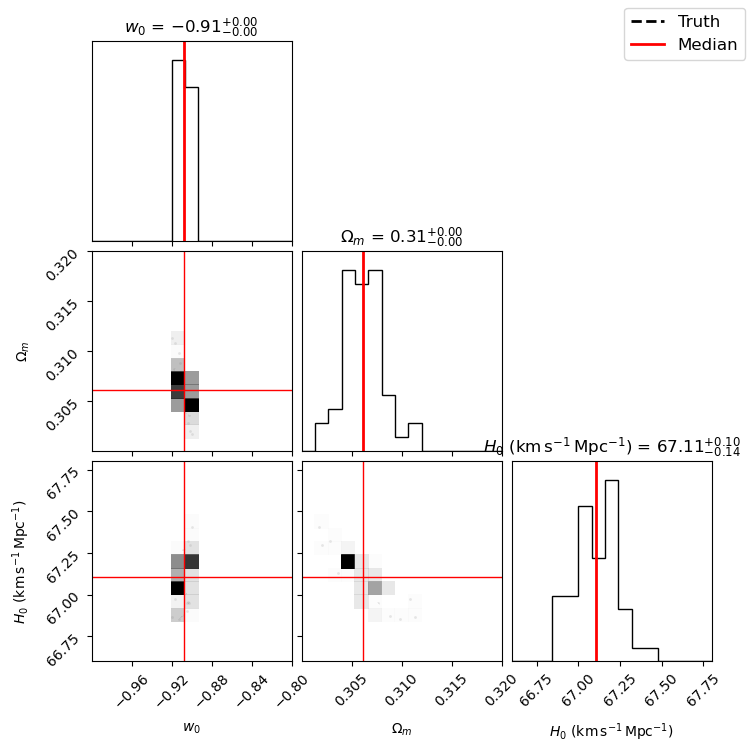

In [16]:
#Corner plots

samples_w = np.vstack([
    Wtgt,
    Om0wtgt,
    HUBwtgt,
]).T

medianw = [np.median(Wtgt), np.median(Om0wtgt), np.median(HUBwtgt)]

ranges = [
    (-1, -0.8),
    (0.3, 0.32),
    (66.6, 67.8),
]


labels =[
    r"$w_0$",
    r"$\Omega_m$",
    r"$H_0\ \mathrm{(km\,s^{-1}\,Mpc^{-1})}$"
]

# Create corner plot
fig = corner.corner(
    samples_w,
    labels=labels,
    show_titles=True,
    range=ranges,
    plot_datapoints=True,
    fill_contours=False,
    plot_contours=False,
    bins=15
)

# Add median lines manually
ndim = samples_w.shape[1]
axes = np.array(fig.axes).reshape((ndim, ndim))

for i in range(ndim):
    ax = axes[i, i]
    ax.axvline(medianw[i], color="red", lw=2)

for i in range(ndim):
    for j in range(i):
        ax = axes[i, j]
        ax.axvline(medianw[j], color="red", lw=1)
        ax.axhline(medianw[i], color="red", lw=1)

#Add legend
truth_line = mlines.Line2D([], [], color='black', lw=2, linestyle='--', label='Truth')
median_line = mlines.Line2D([], [], color='red', lw=2, label='Median')

fig.legend(handles=[truth_line, median_line], loc="upper right", fontsize=12)

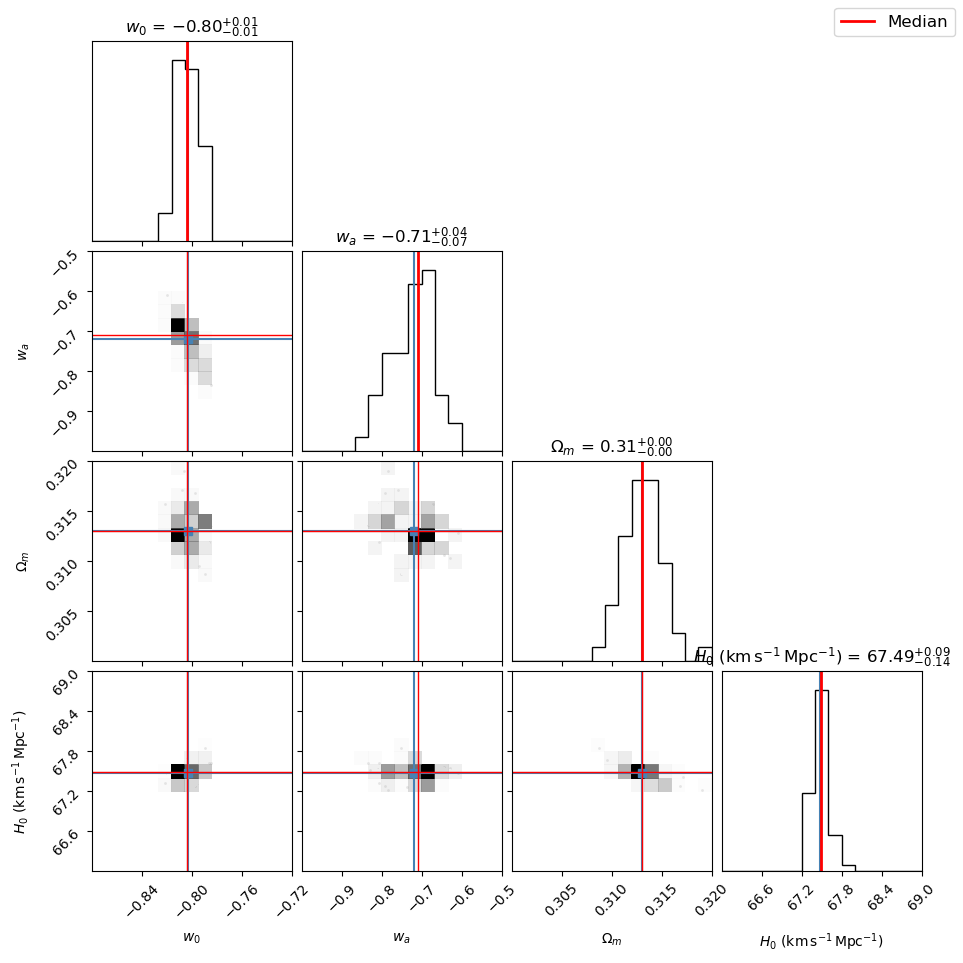

In [17]:
samples_w0wa = np.vstack([
    W0tgt,
    WAtgt,
    Om0waw0tgt,
    HUBwaw0tgt,
]).T 

medianw0wa = [np.median(W0tgt), np.median(WAtgt), np.median(Om0waw0tgt), np.median(HUBwaw0tgt)]

truths = [w, wa, 0.313, H0]

ranges_w0wa = [
    (-0.88, -0.72),
    (-1, -0.5),
    (0.3, 0.32),
    (66, 69),
]

labels2 =[
    r"$w_0$",
    r"$w_a$",
    r"$\Omega_m$",
    r"$H_0\ \mathrm{(km\,s^{-1}\,Mpc^{-1})}$"
]

fig = corner.corner(
    samples_w0wa,
    labels=labels2,
    show_titles=True,
    truths = truths,
    range=ranges_w0wa,
    plot_datapoints=True,
    fill_contours=False,
    plot_contours=False,
    bins=15
)

ndim = samples_w0wa.shape[1]
axes = np.array(fig.axes).reshape((ndim, ndim))

for i in range(ndim):
    ax = axes[i, i]
    ax.axvline(medianw0wa[i], color="red", lw=2, label="Median")

for i in range(ndim):
    for j in range(i):
        ax = axes[i, j]
        ax.axvline(medianw0wa[j], color="red", lw=1)
        ax.axhline(medianw0wa[i], color="red", lw=1)

median_line = mlines.Line2D([], [], color='red', lw=2, label='Median')
fig.legend(handles=[median_line], loc="upper right", fontsize=12)

In [18]:
print(np.median(W0tgt), np.std(W0tgt))
print(np.median(WAtgt), np.std(WAtgt))
print(np.median(HUBwaw0tgt), np.std(HUBwaw0tgt))
print(np.median(Om0waw0tgt), np.std(Om0waw0tgt))

print(np.median(Wtgt), np.std(Wtgt))
print(np.median(HUBwtgt), np.std(HUBwtgt))
print(np.median(Om0wtgt), np.std(Om0wtgt))

print(np.median(HUBLtgt), np.std(HUBLtgt))
print(np.median(Om0Ltgt), np.std(Om0Ltgt))

-0.8035261273718624 0.008651438300766461
-0.7082652971115371 0.053402562473024565
67.49480692455889 0.12407238381875714
0.3130223559153571 0.0019773210790562288
-0.9073950333804757 0.0045457421238466415
67.1093004227449 0.12453792950572917
0.30610015623390835 0.0019299329619576978
66.1867988256237 0.12341684241568357
0.3331012096472039 0.0016014595119304734


In [19]:
#Calculating the mean preferences
preference_w0waCDM_over_wCDM = ev_w0wa - ev_w

preference_w0waCDM_over_LCDM = ev_w0wa - ev_L

In [20]:
print(np.mean(preference_w0waCDM_over_LCDM))

262.0564210189607


In [21]:
print(np.mean(preference_w0waCDM_over_wCDM))

81.92106977515286


Text(0, 0.5, 'Observed Coverage Fraction')

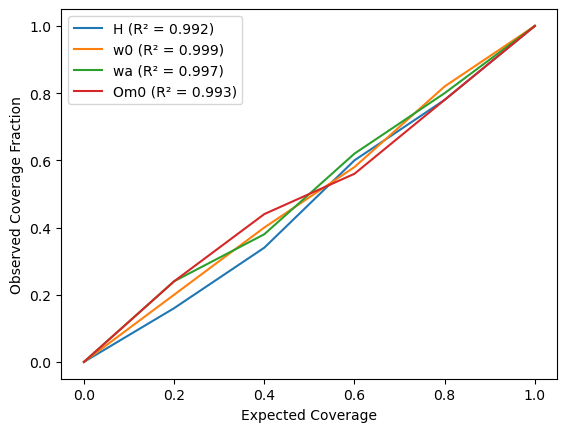

In [22]:
#coverage test graph

confidence_regions = [0, 0.2, 0.4, 0.6, 0.8, 1.0]

H_obs = pipelineH/50
w0_obs = pipelinew0/50
wa_obs = pipelinewa/50
Om0_obs = pipelineOm0/50

r2_H = r2_score(confidence_regions, H_obs)
r2_w0 = r2_score(confidence_regions, w0_obs)
r2_wa = r2_score(confidence_regions, wa_obs)
r2_Om0 = r2_score(confidence_regions, Om0_obs)

plt.plot(confidence_regions, H_obs, label=f"H (R² = {r2_H:.3f})")
plt.plot(confidence_regions, w0_obs, label=f"w0 (R² = {r2_w0:.3f})")
plt.plot(confidence_regions, wa_obs, label=f"wa (R² = {r2_wa:.3f})")
plt.plot(confidence_regions, Om0_obs, label=f"Om0 (R² = {r2_Om0:.3f})")

plt.legend()
plt.xlabel("Expected Coverage")
plt.ylabel("Observed Coverage Fraction")